In [6]:
import sympy
import numpy as np
import matplotlib.pyplot as plt
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame
from dms import getComponents
import scipy
from scipy.optimize import fsolve, least_squares
import matplotlib.animation as animation
from IPython.display import HTML

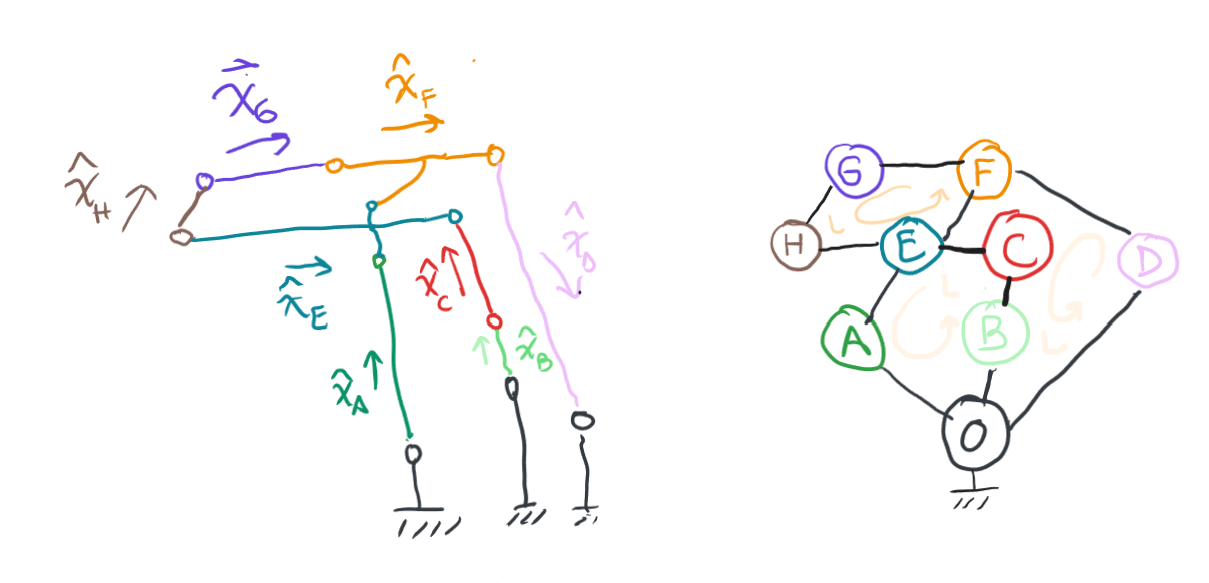

In [99]:

bodies=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
theta = dynamicsymbols(('theta_{} '*len(bodies)).format(*bodies))
N=ReferenceFrame('N')
frames=dict(zip(bodies, [N.orientnew(body, 'Axis', [theta[i], N.z]) for i, body in enumerate(bodies)]))

LA01,LB01,LC01,LD01,LG01,LH01= sympy.symbols('LA01 LB01 LC01 LD01 LG01 LH01')
LE01,LE02,LF01,LF02x,LF02y,L001x,L001y,LEEF01x,LEEF01y= sympy.symbols('LE01 LE02 LF01 LF02x LF02y L001x L001y LEEF01x LEEF01y')

params={LA01:80e-3, LB01:35e-3, LC01:80e-3, LD01:80e-3, LG01:80e-3, LH01:20e-3,
        LE01:35e-3, LE02:80e-3, LF01:46e-3, LF02x:36e-3, LF02y:17e-3, L001x:36e-3, L001y:17e-3, LEEF01x:17e-3, LEEF01y:30e-3}
limits=(np.deg2rad([90-45,-60]),np.deg2rad([90+45,90]))

points = dict()
points['O0'] = 0*N.x
points['O1'] = points['O0'] + L001x*N.x + L001y*N.y
points['Acm']=LA01*frames['A'].x/2
points['A1']=LA01*frames['A'].x
points['Bcm']=LB01*frames['B'].x/2
points['B1']=LB01*frames['B'].x
points['Ccm']=points['B1']+LC01*frames['C'].x/2
points['C1']=points['B1']+LC01*frames['C'].x
points['Dcm']=points['B1']-LD01*frames['D'].x/2
points['D1']=points['B1']-LD01*frames['D'].x
points['E0']=points['C1']-LE01*frames['E'].x
points['E2']=points['C1']-(LE01+LE02)*frames['E'].x
points['H1']=points['E2']+LH01*frames['H'].x
points['G1']=points['H1']+LG01*frames['G'].x
points['F1']=points['G1']+LF01*frames['F'].x
points['EEF1']=points['E2']+LEEF01x*frames['H'].x+LEEF01y*frames['H'].y
points_fun={k:sympy.lambdify(theta,[v.dot(N.x).subs(params),v.dot(N.y).subs(params)]) for k,v in points.items()}

# Loop equations:
eqL1=points['E0']+LF02x*frames['F'].x+LF02y*frames['F'].y+LD01*frames['D'].x-points['O1']
eqL2=points['E0']-points['A1']
eqL3=LH01*frames['H'].x+LG01*frames['G'].x+(LF01-LF02x)*frames['F'].x-LF02y*frames['F'].y-LE02*frames['E'].x

eq=getComponents(eqL1, N)[0:2]+getComponents(eqL2, N)[0:2]+getComponents(eqL3, N)[0:2]
eq=[eq.subs(params) for eq in eq]
eq_fun=sympy.lambdify(theta, eq, 'numpy')

def FK(thetaA,thetaB,z0=None):    
    if z0 is None:
        z0=np.deg2rad([90, -90, 0, 0, 0, 100])  
    sln=fsolve(lambda z: eq_fun(thetaA,thetaB,*z),z0)    
    return sln

def IK(x,y,x0=None,z0=None):
    if z0 is None:
        z0=np.deg2rad([90, -90, 0, 0, 0, 100]) 
    if x0 is None:
        x0=np.deg2rad([90, 0]) 
    def IK_fun(qpos,z0=z0):                
        z=FK(*qpos,z0=z0)
        eef=points_fun['EEF1'](*qpos,*z)        
        er=1000*np.linalg.norm(eef-np.array([x,y]))                
        return er
    #print(limits)
    sln=least_squares(IK_fun,x0,bounds=limits)
    if not sln.success:
        print("IK failed to converge")
        return None    
    return sln.x

def plotMechanism(thetas,ax=None):
    if len(thetas)==2:
        z=FK(*thetas)
        thetas=np.concatenate([thetas,z])
    O0=points_fun['O0'](*thetas)
    O1=points_fun['O1'](*thetas)    
    A1=points_fun['A1'](*thetas)     
    B1=points_fun['B1'](*thetas)    
    C1=points_fun['C1'](*thetas) 
    E0=points_fun['E0'](*thetas)
    E2=points_fun['E2'](*thetas)
    H1=points_fun['H1'](*thetas)
    G1=points_fun['G1'](*thetas)
    F1=points_fun['F1'](*thetas)
    EEF1=points_fun['EEF1'](*thetas)
    if ax is None:
        ax=plt.figure().add_subplot(111)
    ax.plot(O0[0],O0[1], 'ko')
    ax.plot(O1[0],O1[1], 'ko')
    ax.plot([O0[0],A1[0]], [O0[1],A1[1]], 'green')
    ax.plot(A1[0],A1[1], 'ko')
    ax.plot([O0[0],B1[0]], [O0[1],B1[1]], 'turquoise')
    ax.plot(B1[0],B1[1], 'ko')
    ax.plot([B1[0],C1[0]], [B1[1],C1[1]], 'red')
    ax.plot(C1[0],C1[1], 'ko')
    ax.plot([C1[0],E2[0]], [C1[1],E2[1]], 'blue')
    ax.plot(E2[0],E2[1], 'ko')
    ax.plot(E0[0],E0[1], 'ko')
    ax.plot([E2[0],H1[0]], [E2[1],H1[1]], 'brown')
    ax.plot([E2[0],EEF1[0]], [E2[1],EEF1[1]], 'brown')
    ax.plot(H1[0],H1[1], 'ko')
    ax.plot(EEF1[0],EEF1[1], 'k*')
    ax.plot([H1[0],G1[0]], [H1[1],G1[1]], 'magenta')
    ax.plot(G1[0],G1[1], 'ko')
    ax.plot([G1[0],F1[0]], [G1[1],F1[1]], 'orange')
    ax.plot([G1[0],E0[0]], [G1[1],E0[1]], 'orange')
    ax.plot([F1[0],E0[0]], [F1[1],E0[1]], 'orange')
    ax.plot(F1[0],F1[1], 'ko')
    ax.plot([F1[0],O1[0]], [F1[1],O1[1]], 'pink')
    ax.set_aspect('equal')
    ax.set_xlim(-0.18,0.15)
    ax.set_ylim(-0.1,0.20)


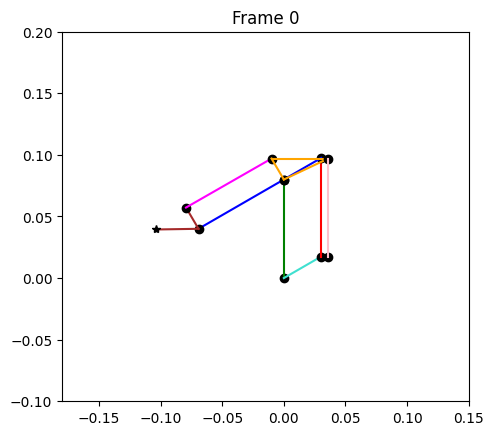

In [11]:
n_frames=60
theta1_val=np.linspace(90,110,n_frames)
fig, ax = plt.subplots()
#Angles initial guess:
# theta_C, theta_D, ...
z0=np.deg2rad([90, -90, 0, 0, 0, 100])

def animate(i):
    global z0
    ax.clear()  # Clear the previous frame
    x=np.deg2rad(theta1_val[i]), np.deg2rad(30)
    z=FK(*x,z0=z0)
    z0=z
    plotMechanism([*x, *z],ax)    
    ax.set_title(f"Frame {i}")

ani = animation.FuncAnimation(fig, animate, frames=n_frames, repeat=False,interval=20)
HTML(ani.to_jshtml())

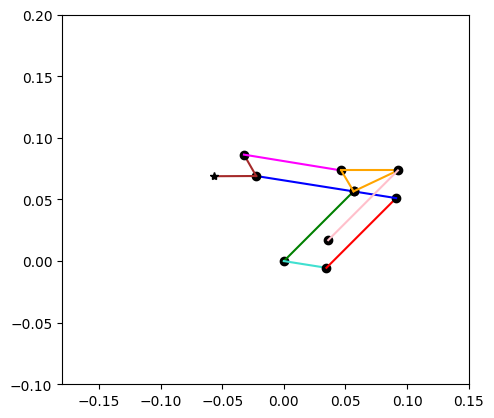

In [102]:
sln=IK(-0.05, 0.0678)
plotMechanism(sln)


[np.float64(-0.08681426831048786), np.float64(0.06787334297933198)]

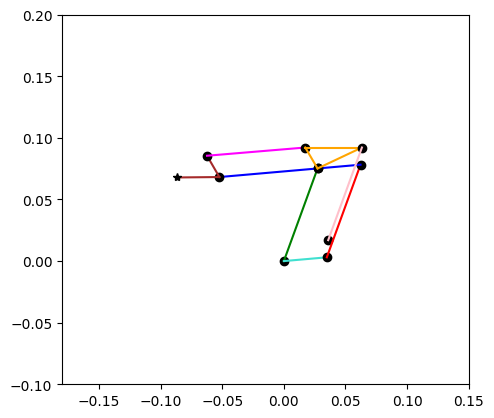

In [92]:
np.rad2deg(z0)

array([ 6.99938106e+01, -1.10006189e+02,  5.05023696e+00,  1.44683569e-09,
        4.83080444e+00,  1.20087324e+02])